In [ ]:
import os
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import norm
import sys
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.utils import resample

class ClassicWisard:

    def __init__(self, num_inputs, num_classes, tuple_size, ignore_zero=False):
        """
        num_inputs: número total de bits de entrada (deve ser múltiplo de tuple_size)
        num_classes: número de classes (discriminadores)
        tuple_size: número de bits por RAM node (address size)
        ignore_zero: se True, o endereço 0 é ignorado (não treina nem infere)
        """
        self.num_inputs = num_inputs
        self.num_classes = num_classes
        self.tuple_size = tuple_size
        self.ignore_zero = ignore_zero
        
        if num_inputs % tuple_size != 0:
            raise ValueError(f"num_inputs ({num_inputs}) deve ser múltiplo de tuple_size ({tuple_size})")
        
        self.num_nodes = num_inputs // tuple_size
        
        self.discriminators = []
        for _ in range(num_classes):
            nodes = [dict() for _ in range(self.num_nodes)]
            self.discriminators.append(nodes)
    
    def _get_address(self, xv, node_idx):
        start = node_idx * self.tuple_size
        end = start + self.tuple_size
        bits = xv[start:end]
        addr = 0
        for i, b in enumerate(bits):
            if b:
                addr |= (1 << i)
        return addr
    
    def train(self, xv, label):
        nodes = self.discriminators[label]
        for node_idx in range(self.num_nodes):
            addr = self._get_address(xv, node_idx)
            if self.ignore_zero and addr == 0:
                continue
            nodes[node_idx][addr] = nodes[node_idx].get(addr, 0) + 1
    
    def predict(self, xv, bleach=1):
        responses = []
        for disc in self.discriminators:
            total = 0
            for node_idx, node in enumerate(disc):
                addr = self._get_address(xv, node_idx)
                if self.ignore_zero and addr == 0:
                    continue
                if node.get(addr, 0) >= bleach:
                    total += 1
            responses.append(total)
        
        max_response = max(responses)
        best_classes = [i for i, r in enumerate(responses) if r == max_response]
        
        return int(np.random.choice(best_classes))
    
    def get_max_counter(self):
        max_val = 0
        for disc in self.discriminators:
            for node in disc:
                if node:
                    max_val = max(max_val, max(node.values()))
        return max_val
    
    def set_bleaching(self, bleach):
        pass

# ==========================================================
# BALANCEAMENTO
# ==========================================================
def balance_dataset_undersample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_min = np.sum(y == class_min)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_maj_bal = resample(idx_maj, replace=False, n_samples=count_min, random_state=42)
    balanced_idx = np.concatenate([idx_min, idx_maj_bal])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

def balance_dataset_oversample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_maj = np.sum(y == class_maj)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_min_over = resample(idx_min, replace=True, n_samples=count_maj, random_state=42)
    balanced_idx = np.concatenate([idx_min_over, idx_maj])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

# ==========================================================
# BINARIZAÇÃO
# ==========================================================
def encode_features(X_tr, X_val, X_te, bpt):
    X_tr_parts, X_val_parts, X_te_parts = [], [], []
    
    for col in X_tr.columns:
        s_tr = X_tr[col]
        s_val = X_val[col]
        s_te = X_te[col]
        
        if s_tr.dtype == 'object' or s_tr.dtype.name == 'string':
            s_tr = s_tr.astype(str).str.strip().str.lower()
            s_val = s_val.astype(str).str.strip().str.lower()
            s_te = s_te.astype(str).str.strip().str.lower()
            
        nunique = s_tr.nunique()
        
        if nunique <= 1:
            continue
            
        elif nunique == 2:
            valores_unicos = sorted(s_tr.dropna().unique())
            mapeamento = {valores_unicos[0]: 0, valores_unicos[1]: 1}
            X_tr_parts.append(s_tr.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_val_parts.append(s_val.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_te_parts.append(s_te.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            
        elif pd.api.types.is_numeric_dtype(s_tr):
            val_tr = pd.to_numeric(s_tr, errors='coerce').fillna(0).values.astype(float)
            media, desvio = np.mean(val_tr), np.std(val_tr)
            limiares = norm.ppf(np.linspace(0, 1, bpt + 2)[1:-1], loc=media, scale=desvio) if desvio > 0 else []
            
            def aplica_gauss(serie):
                val = pd.to_numeric(serie, errors='coerce').fillna(0).values.astype(float)
                if desvio == 0:
                    return np.zeros((len(val), bpt), dtype=int)
                return np.array([
                    [1] * np.sum(v > limiares) + [0] * (bpt - np.sum(v > limiares))
                    for v in val
                ], dtype=int)
            
            X_tr_parts.append(aplica_gauss(s_tr))
            X_val_parts.append(aplica_gauss(s_val))
            X_te_parts.append(aplica_gauss(s_te))
            
        else:
            enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
            X_tr_parts.append(enc.fit_transform(s_tr.values.reshape(-1, 1)))
            X_val_parts.append(enc.transform(s_val.values.reshape(-1, 1)))
            X_te_parts.append(enc.transform(s_te.values.reshape(-1, 1)))
            
    return np.hstack(X_tr_parts), np.hstack(X_val_parts), np.hstack(X_te_parts)

# ==========================================================
# FUNÇÃO DE AVALIAÇÃO PARA ClassicWisard
# ==========================================================
def evaluate_config(params, X_tr, y_tr, X_val, y_val):
    tuple_size, ignore_zero = params
    modelo = ClassicWisard(X_tr.shape[1], 2, tuple_size, ignore_zero)
    
    for i in range(len(X_tr)):
        modelo.train(X_tr[i].tolist(), int(y_tr[i]))
    
    max_val = modelo.get_max_counter()
    if max_val <= 1:
        best_bleach = 1
        y_pred = [modelo.predict(x.tolist(), best_bleach) for x in X_val]
        best_acc = float(accuracy_score(y_val, y_pred))
        best_f1 = float(f1_score(y_val, y_pred, zero_division=0))
        return (tuple_size, ignore_zero, best_bleach, best_acc, best_f1)
    
    best_bleach = max_val // 2
    step = max(max_val // 4, 1)
    bleach_accuracies = {}
    while True:
        candidates = [best_bleach - step, best_bleach, best_bleach + step]
        accuracies = []
        for b in candidates:
            if b in bleach_accuracies:
                accuracies.append(bleach_accuracies[b])
            elif b < 1:
                accuracies.append(0)
            else:
                y_pred = [modelo.predict(x.tolist(), b) for x in X_val]
                acc = float(accuracy_score(y_val, y_pred))
                bleach_accuracies[b] = acc
                accuracies.append(acc)
        new_best = candidates[accuracies.index(max(accuracies))]
        if (new_best == best_bleach) and (step == 1):
            break
        best_bleach = new_best
        if step > 1:
            step //= 2
    
    y_pred_final = [modelo.predict(x.tolist(), best_bleach) for x in X_val]
    best_acc = float(accuracy_score(y_val, y_pred_final))
    best_f1 = float(f1_score(y_val, y_pred_final, zero_division=0))
    return (tuple_size, ignore_zero, best_bleach, best_acc, best_f1)

# ==========================================================
# CONFIGURAÇÕES PARA O GRID SEARCH
# ==========================================================
caminho_datasets = "./Datasets"
arquivos = [
    "IoT_Fridge.csv",
    "IoT_Garage_Door.csv",
    "IoT_GPS_Tracker.csv",
    "IoT_Modbus.csv",
    "IoT_Motion_Light.csv",
    "IoT_Thermostat.csv",
    "IoT_Weather.csv"
]

bits_por_termo = [4, 8, 16]                # tamanho do termômetro
# tuple_sizes = [2, 4, 6, 8, 12, 16, 20, 24] # número de bits por RAM node
ignore_zero_opts = [True, False]           # ignorar endereço 0 ou não
balance_method = 'undersample'             # undersample ou oversample

resultados_finais = []

print("INICIANDO GRID SEARCH PARA WISARD CLÁSSICO")
print(f"Bits por termômetro: {bits_por_termo}")
print(f"Ignore zero: {ignore_zero_opts}")
print(f"Balanceamento: {balance_method}\n")

for arquivo in arquivos:
    nome_sensor = arquivo.replace("IoT_", "").replace(".csv", "")
    print(f"\nProcessando {nome_sensor.upper()}...")

    # Carrega e limpa dados
    df = pd.read_csv(os.path.join(caminho_datasets, arquivo), low_memory=False)
    df.columns = df.columns.str.strip()
    for col in ['date','time','ts','timestamp']:
        if col in df.columns:
            df.drop(columns=col, inplace=True)
    if 'sphone_signal' in df.columns:
        df['sphone_signal'] = df['sphone_signal'].astype(str).str.strip().str.lower()
        df['sphone_signal'] = df['sphone_signal'].replace({'0':'false','0.0':'false','1':'true','1.0':'true'})
    
    label_col = [c for c in df.columns if 'label' in c.lower()][0]
    y = df[label_col].values.astype(int)
    X_raw = df.drop(columns=[c for c in df.columns if 'label' in c.lower() or 'type' in c.lower()], errors='ignore')

    X_raw_tr_full, X_raw_te, y_tr_full, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
    X_raw_tr, X_raw_val, y_tr, y_val = train_test_split(X_raw_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full)

    melhor_global = None

    for bpt in bits_por_termo:
        print(f"  Bits por termômetro = {bpt}")

        # Binarização
        X_tr_bin, X_val_bin, X_te_bin = encode_features(X_raw_tr, X_raw_val, X_raw_te, bpt)
        num_inputs_total = X_tr_bin.shape[1]
        print(f"    Total de bits após binarização: {num_inputs_total}")

        divisors = [d for d in range(1, min(25, num_inputs_total+1)) if num_inputs_total % d == 0]
        print(f"    Tuplas válidas: {divisors}")
        
        # Balanceamento
        if balance_method == 'undersample':
            X_tr_bal, y_tr_bal = balance_dataset_undersample(X_tr_bin, y_tr)
        else:
            X_tr_bal, y_tr_bal = balance_dataset_oversample(X_tr_bin, y_tr)
        print(f"    Treino balanceado: {len(X_tr_bal)} amostras, distribuição {pd.Series(y_tr_bal).value_counts().to_dict()}")

        combinacoes = []
        for ts in divisors:
            if ts > num_inputs_total:
                continue
            if num_inputs_total % ts != 0:
                continue
            for ign in ignore_zero_opts:
                combinacoes.append((ts, ign))
        
        if not combinacoes:
            print(f"    Nenhuma combinação válida para bpt={bpt} (total bits {num_inputs_total})")
            continue
        
        num_workers = min(cpu_count(), len(combinacoes))
        print(f"    Testando {len(combinacoes)} combinações com {num_workers} workers...")
        eval_partial = partial(evaluate_config, X_tr=X_tr_bal, y_tr=y_tr_bal, X_val=X_val_bin, y_val=y_val)
        
        with Pool(num_workers) as pool:
            resultados = pool.map(eval_partial, combinacoes)
        
        for (ts, ign, bleach, acc, f1) in resultados:
            acc = float(acc)
            f1 = float(f1)
            if melhor_global is None or (f1 > melhor_global[5]) or (f1 == melhor_global[5] and acc > melhor_global[4]):
                melhor_global = (bpt, ts, ign, bleach, acc, f1, X_tr_bal, y_tr_bal, X_te_bin)

        print(f"    Melhor atual (bits={bpt}): Val_F1={melhor_global[5]:.4f}, Val_Acc={melhor_global[4]:.4f}")
    
    # ==========================================================
    # AVALIAÇÃO FINAL NO TESTE ISOLADO
    # ==========================================================
    if melhor_global is None:
        print(f"  Nenhuma configuração válida para {nome_sensor}. Pulando.")
        continue

    bpt, ts, ign, bleach, _, _, X_tr_bal, y_tr_bal, X_te_bin = melhor_global
    
    # Treinamento do modelo final
    modelo_final = ClassicWisard(X_tr_bal.shape[1], 2, ts, ign)
    start_train = time.time()
    for i in range(len(X_tr_bal)):
        modelo_final.train(X_tr_bal[i].tolist(), int(y_tr_bal[i]))
    train_t = time.time() - start_train

    start_test = time.time()
    preds = [modelo_final.predict(x.tolist(), bleach) for x in X_te_bin]
    test_t = time.time() - start_test

    test_acc = accuracy_score(y_te, preds)
    test_prec = precision_score(y_te, preds, zero_division=0)
    test_rec = recall_score(y_te, preds, zero_division=0)
    test_f1 = f1_score(y_te, preds, zero_division=0)
    cm = confusion_matrix(y_te, preds)

    print(f"  Teste Real - Matriz de Confusão:\n      TN={cm[0,0]} FP={cm[0,1]}\n      FN={cm[1,0]} TP={cm[1,1]}")
    print(f"  Acurácia: {test_acc:.4f}, Precisão: {test_prec:.4f}, Recall: {test_rec:.4f}, F1: {test_f1:.4f}")

    resultados_finais.append({
        'Dataset': nome_sensor.capitalize(),
        'Accuracy': test_acc,
        'Precision': test_prec,
        'Recall': test_rec,
        'F-Score': test_f1,
        'Train Time (s)': train_t,
        'Test Time (s)': test_t,
        'Config': f"tuple={ts}, ignoreZero={ign}, bleach={bleach}, bits_term={bpt}"
    })
    print(f" Configuração vencedora: {resultados_finais[-1]['Config']}\n")

# ==========================================================
# TABELA FINAL
# ==========================================================
print("\n" + "="*115)
print(" 📊 TABELA DE MÉTRICAS FINAIS - WISARD CLÁSSICO (BUSCA ADAPTATIVA DO BLEACHING)")
print("="*115)
df_res = pd.DataFrame(resultados_finais)
for col in ['Accuracy', 'Precision', 'Recall', 'F-Score', 'Train Time (s)', 'Test Time (s)']:
    df_res[col] = df_res[col].apply(lambda x: f"{float(x):.4f}")
print(df_res.to_string(index=False))
print("="*115)

🤖 INICIANDO GRID SEARCH PARA WISARD CLÁSSICO (RAM nodes com dicionários)
Bits por termômetro: [4, 8, 16]
Ignore zero: [True, False]
Balanceamento: undersample


🔄 Processando FRIDGE...
  Bits por termômetro = 4
    Total de bits após binarização: 10
    Tuplas válidas: [1, 2, 5, 10]
    Treino balanceado: 110398 amostras, distribuição {0: 55199, 1: 55199}
    Testando 8 combinações com 8 workers...
    Melhor atual (bits=4): Val_F1=0.5552, Val_Acc=0.7646
  Bits por termômetro = 8
    Total de bits após binarização: 14
    Tuplas válidas: [1, 2, 7, 14]
    Treino balanceado: 110398 amostras, distribuição {1: 55199, 0: 55199}
    Testando 8 combinações com 8 workers...
    Melhor atual (bits=8): Val_F1=0.5552, Val_Acc=0.7646
  Bits por termômetro = 16
    Total de bits após binarização: 22
    Tuplas válidas: [1, 2, 11, 22]
    Treino balanceado: 110398 amostras, distribuição {1: 55199, 0: 55199}
    Testando 8 combinações com 8 workers...
    Melhor atual (bits=16): Val_F1=0.5552, Val_A

In [ ]:
import os
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import norm
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.utils import resample

class ClassicWisard:
    def __init__(self, num_inputs, num_classes, tuple_size, ignore_zero=False):
        self.num_inputs = num_inputs
        self.num_classes = num_classes
        self.tuple_size = tuple_size
        self.ignore_zero = ignore_zero
        
        if num_inputs % tuple_size != 0:
            raise ValueError(f"num_inputs ({num_inputs}) deve ser múltiplo de tuple_size ({tuple_size})")
        
        self.num_nodes = num_inputs // tuple_size
        
        self.discriminators = []
        for _ in range(num_classes):
            nodes = [dict() for _ in range(self.num_nodes)]
            self.discriminators.append(nodes)
    
    def _get_address(self, xv, node_idx):
        start = node_idx * self.tuple_size
        end = start + self.tuple_size
        bits = xv[start:end]
        addr = 0
        for i, b in enumerate(bits):
            if b:
                addr |= (1 << i)
        return addr
    
    def train(self, xv, label):
        nodes = self.discriminators[label]
        for node_idx in range(self.num_nodes):
            addr = self._get_address(xv, node_idx)
            if self.ignore_zero and addr == 0:
                continue
            nodes[node_idx][addr] = nodes[node_idx].get(addr, 0) + 1
    
    def predict(self, xv, bleach=1):
        responses = []
        for disc in self.discriminators:
            total = 0
            for node_idx, node in enumerate(disc):
                addr = self._get_address(xv, node_idx)
                if self.ignore_zero and addr == 0:
                    continue
                if node.get(addr, 0) >= bleach:
                    total += 1
            responses.append(total)
        max_response = max(responses)
        best_classes = [i for i, r in enumerate(responses) if r == max_response]
        return int(np.random.choice(best_classes))
    
    def get_max_counter(self):
        max_val = 0
        for disc in self.discriminators:
            for node in disc:
                if node:
                    max_val = max(max_val, max(node.values()))
        return max_val

# ==========================================================
# BALANCEAMENTO
# ==========================================================
def balance_dataset_undersample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_min = np.sum(y == class_min)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_maj_bal = resample(idx_maj, replace=False, n_samples=count_min, random_state=42)
    balanced_idx = np.concatenate([idx_min, idx_maj_bal])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

def balance_dataset_oversample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_maj = np.sum(y == class_maj)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_min_over = resample(idx_min, replace=True, n_samples=count_maj, random_state=42)
    balanced_idx = np.concatenate([idx_min_over, idx_maj])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

# ==========================================================
# BINARIZAÇÃO
# ==========================================================
def encode_features(X_tr, X_val, X_te, bpt):
    X_tr_parts, X_val_parts, X_te_parts = [], [], []
    
    for col in X_tr.columns:
        s_tr = X_tr[col]
        s_val = X_val[col]
        s_te = X_te[col]
        
        if s_tr.dtype == 'object' or s_tr.dtype.name == 'string':
            s_tr = s_tr.astype(str).str.strip().str.lower()
            s_val = s_val.astype(str).str.strip().str.lower()
            s_te = s_te.astype(str).str.strip().str.lower()
        
        nunique = s_tr.nunique()
        if nunique <= 1:
            continue
        elif nunique == 2:
            valores_unicos = sorted(s_tr.dropna().unique())
            mapeamento = {valores_unicos[0]: 0, valores_unicos[1]: 1}
            X_tr_parts.append(s_tr.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_val_parts.append(s_val.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_te_parts.append(s_te.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
        elif pd.api.types.is_numeric_dtype(s_tr):
            val_tr = pd.to_numeric(s_tr, errors='coerce').fillna(0).values.astype(float)
            media, desvio = np.mean(val_tr), np.std(val_tr)
            if desvio == 0:
                continue
            limiares = norm.ppf(np.linspace(0, 1, bpt + 2)[1:-1], loc=media, scale=desvio)
            def aplica_gauss(serie):
                val = pd.to_numeric(serie, errors='coerce').fillna(0).values.astype(float)
                return np.array([
                    [1] * np.sum(v > limiares) + [0] * (bpt - np.sum(v > limiares))
                    for v in val
                ], dtype=int)
            X_tr_parts.append(aplica_gauss(s_tr))
            X_val_parts.append(aplica_gauss(s_val))
            X_te_parts.append(aplica_gauss(s_te))
        else:
            enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
            X_tr_parts.append(enc.fit_transform(s_tr.values.reshape(-1, 1)))
            X_val_parts.append(enc.transform(s_val.values.reshape(-1, 1)))
            X_te_parts.append(enc.transform(s_te.values.reshape(-1, 1)))
    
    if not X_tr_parts:
        return np.empty((len(X_tr), 0)), np.empty((len(X_val), 0)), np.empty((len(X_te), 0))
    return np.hstack(X_tr_parts), np.hstack(X_val_parts), np.hstack(X_te_parts)

# ==========================================================
# FUNÇÃO DE AVALIAÇÃO
# ==========================================================
def evaluate_config(params, X_tr, y_tr, X_val, y_val):
    tuple_size, ignore_zero = params
    modelo = ClassicWisard(X_tr.shape[1], 2, tuple_size, ignore_zero)
    
    for i in range(len(X_tr)):
        modelo.train(X_tr[i].tolist(), int(y_tr[i]))
    
    max_val = modelo.get_max_counter()
    if max_val <= 1:
        best_bleach = 1
        y_pred = [modelo.predict(x.tolist(), best_bleach) for x in X_val]
        best_acc = float(accuracy_score(y_val, y_pred))
        best_f1 = float(f1_score(y_val, y_pred, zero_division=0))
        return (tuple_size, ignore_zero, best_bleach, best_acc, best_f1)
    
    best_bleach = max_val // 2
    step = max(max_val // 4, 1)
    bleach_accuracies = {}
    while True:
        candidates = [best_bleach - step, best_bleach, best_bleach + step]
        accuracies = []
        for b in candidates:
            if b in bleach_accuracies:
                accuracies.append(bleach_accuracies[b])
            elif b < 1:
                accuracies.append(0)
            else:
                y_pred = [modelo.predict(x.tolist(), b) for x in X_val]
                acc = float(accuracy_score(y_val, y_pred))
                bleach_accuracies[b] = acc
                accuracies.append(acc)
        new_best = candidates[accuracies.index(max(accuracies))]
        if (new_best == best_bleach) and (step == 1):
            break
        best_bleach = new_best
        if step > 1:
            step //= 2
    
    y_pred_final = [modelo.predict(x.tolist(), best_bleach) for x in X_val]
    best_acc = float(accuracy_score(y_val, y_pred_final))
    best_f1 = float(f1_score(y_val, y_pred_final, zero_division=0))
    return (tuple_size, ignore_zero, best_bleach, best_acc, best_f1)

# ==========================================================
# CONFIGURAÇÕES PARA O DATASET CONSOLIDADO
# ==========================================================
caminho_dataset_unificado = "TON_IoT_Consolidado.csv"

bits_por_termo = [4, 8, 16]
ignore_zero_opts = [True, False]
balance_method = 'undersample'

print("🤖 INICIANDO GRID SEARCH PARA WISARD CLÁSSICO (DATASET CONSOLIDADO)")
print(f"Bits por termômetro: {bits_por_termo}")
print(f"Ignore zero: {ignore_zero_opts}")
print(f"Balanceamento: {balance_method}\n")

# Carregar o dataset unificado
df = pd.read_csv(caminho_dataset_unificado, low_memory=False)
if 'timestamp' in df.columns:
    df = df.drop(columns=['timestamp'])

label_col = 'Global_Attack_Label'
if label_col not in df.columns:
    raise ValueError("Coluna 'Global_Attack_Label' não encontrada no dataset consolidado.")

y = df[label_col].values.astype(int)
X_raw = df.drop(columns=[label_col])

print(f"Dataset carregado: {X_raw.shape[0]} amostras, {X_raw.shape[1]} features.")
print(f"Distribuição das labels: {pd.Series(y).value_counts().to_dict()}\n")

# Separação (20% teste, 20% do restante para validação)
X_raw_tr_full, X_raw_te, y_tr_full, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_raw_tr, X_raw_val, y_tr, y_val = train_test_split(X_raw_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full)

print(f"Tamanhos: Treino={len(X_raw_tr)} | Validação={len(X_raw_val)} | Teste={len(X_raw_te)}")

melhor_global = None

for bpt in bits_por_termo:
    print(f"\nBits por termômetro = {bpt}")
    
    X_tr_bin, X_val_bin, X_te_bin = encode_features(X_raw_tr, X_raw_val, X_raw_te, bpt)
    num_inputs_total = X_tr_bin.shape[1]
    print(f"  Total de bits após binarização: {num_inputs_total}")
    
    if balance_method == 'undersample':
        X_tr_bal, y_tr_bal = balance_dataset_undersample(X_tr_bin, y_tr)
    else:
        X_tr_bal, y_tr_bal = balance_dataset_oversample(X_tr_bin, y_tr)
    print(f"  Treino balanceado: {len(X_tr_bal)} amostras, distribuição {pd.Series(y_tr_bal).value_counts().to_dict()}")
    
    divisors = [d for d in range(1, min(25, num_inputs_total+1)) if num_inputs_total % d == 0]
    print(f"  Tuplas válidas: {divisors}")
    
    combinacoes = []
    for ts in divisors:
        for ign in ignore_zero_opts:
            combinacoes.append((ts, ign))
    
    if not combinacoes:
        print("  Nenhuma combinação válida.")
        continue
    
    num_workers = min(cpu_count(), len(combinacoes))
    print(f"  Testando {len(combinacoes)} combinações com {num_workers} workers...")
    eval_partial = partial(evaluate_config, X_tr=X_tr_bal, y_tr=y_tr_bal, X_val=X_val_bin, y_val=y_val)
    
    with Pool(num_workers) as pool:
        resultados = pool.map(eval_partial, combinacoes)
    
    # Seleciona melhor configuração
    for (ts, ign, bleach, acc, f1) in resultados:
        acc = float(acc)
        f1 = float(f1)
        if melhor_global is None or (f1 > melhor_global[5]) or (f1 == melhor_global[5] and acc > melhor_global[4]):
            melhor_global = (bpt, ts, ign, bleach, acc, f1, X_tr_bal, y_tr_bal, X_te_bin)
    
    print(f"  Melhor até agora (bits={bpt}): Val_F1={melhor_global[5]:.4f}, Val_Acc={melhor_global[4]:.4f}")

# ==========================================================
# AVALIAÇÃO FINAL NO TESTE ISOLADO
# ==========================================================
if melhor_global is None:
    raise RuntimeError("Nenhuma configuração válida encontrada.")

bpt, ts, ign, bleach, _, _, X_tr_bal, y_tr_bal, X_te_bin = melhor_global

print("\n" + "="*80)
print("TREINANDO MODELO FINAL COM A MELHOR CONFIGURAÇÃO...")
print("="*80)

modelo_final = ClassicWisard(X_tr_bal.shape[1], 2, ts, ign)
start_train = time.time()
for i in range(len(X_tr_bal)):
    modelo_final.train(X_tr_bal[i].tolist(), int(y_tr_bal[i]))
train_t = time.time() - start_train

start_test = time.time()
preds = [modelo_final.predict(x.tolist(), bleach) for x in X_te_bin]
test_t = time.time() - start_test

test_acc = accuracy_score(y_te, preds)
test_prec = precision_score(y_te, preds, zero_division=0)
test_rec = recall_score(y_te, preds, zero_division=0)
test_f1 = f1_score(y_te, preds, zero_division=0)
cm = confusion_matrix(y_te, preds)

print("\n" + "="*80)
print("RESULTADOS FINAIS - WiSARD CLÁSSICO")
print("="*80)
print(f"Matriz de Confusão no Teste:")
print(f"  TN={cm[0,0]}   FP={cm[0,1]}")
print(f"  FN={cm[1,0]}   TP={cm[1,1]}")
print(f"\nAcurácia : {test_acc:.4f}")
print(f"Precisão: {test_prec:.4f}")
print(f"Recall  : {test_rec:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"Tempo de treino: {train_t:.2f} s")
print(f"Tempo de teste : {test_t:.2f} s")
print(f"Melhor configuração: tuple={ts}, ignoreZero={ign}, bleach={bleach}, bits_term={bpt}")

🤖 INICIANDO GRID SEARCH PARA WISARD CLÁSSICO (DATASET CONSOLIDADO)
Bits por termômetro: [4, 8, 16]
Ignore zero: [True, False]
Balanceamento: undersample

Dataset carregado: 400544 amostras, 17 features.
Distribuição das labels: {0: 291745, 1: 108799}

Tamanhos: Treino=256348 | Validação=64087 | Teste=80109

Bits por termômetro = 4
  Total de bits após binarização: 56
  Treino balanceado: 139262 amostras, distribuição {0: 69631, 1: 69631}
  Tuplas válidas: [1, 2, 4, 7, 8, 14]
  Testando 12 combinações com 12 workers...
  Melhor até agora (bits=4): Val_F1=0.3672, Val_Acc=0.6420

Bits por termômetro = 8
  Total de bits após binarização: 108
  Treino balanceado: 139262 amostras, distribuição {1: 69631, 0: 69631}
  Tuplas válidas: [1, 2, 3, 4, 6, 9, 12, 18]
  Testando 16 combinações com 12 workers...
  Melhor até agora (bits=8): Val_F1=0.3672, Val_Acc=0.6420

Bits por termômetro = 16
  Total de bits após binarização: 212
  Treino balanceado: 139262 amostras, distribuição {1: 69631, 0: 69631

/tmp/ipykernel_3866/1895508404.py:90: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3866/1895508404.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('tabela_wisard_classico_com_global.png', dpi=200, bbox_inches='tight')


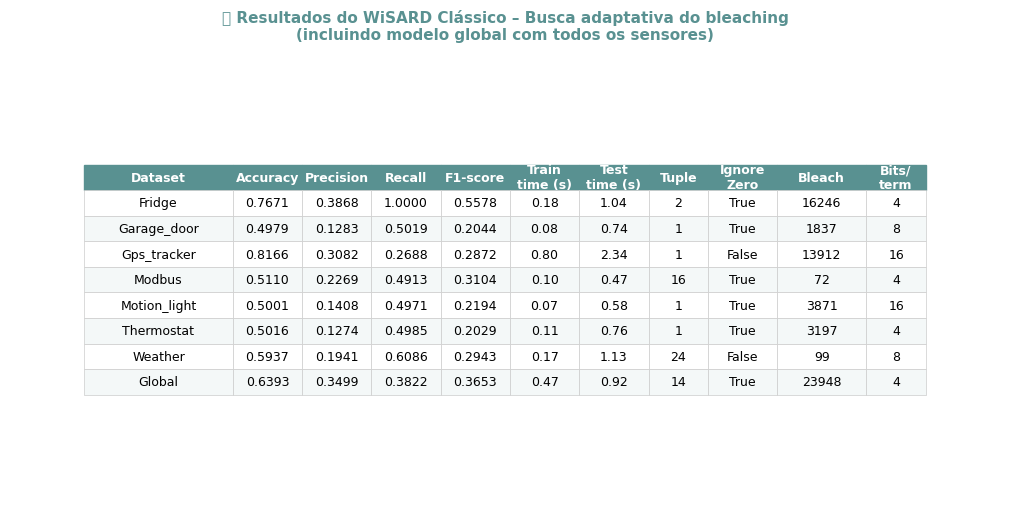

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados individuais
data_individual = [
    ["Fridge", 0.7671, 0.3868, 1.0000, 0.5578, 0.1784, 1.0380, 2, "True", 16246, 4],
    ["Garage_door", 0.4979, 0.1283, 0.5019, 0.2044, 0.0751, 0.7425, 1, "True", 1837, 8],
    ["Gps_tracker", 0.8166, 0.3082, 0.2688, 0.2872, 0.7979, 2.3379, 1, "False", 13912, 16],
    ["Modbus", 0.5110, 0.2269, 0.4913, 0.3104, 0.1000, 0.4697, 16, "True", 72, 4],
    ["Motion_light", 0.5001, 0.1408, 0.4971, 0.2194, 0.0658, 0.5765, 1, "True", 3871, 16],
    ["Thermostat", 0.5016, 0.1274, 0.4985, 0.2029, 0.1080, 0.7598, 1, "True", 3197, 4],
    ["Weather", 0.5937, 0.1941, 0.6086, 0.2943, 0.1749, 1.1264, 24, "False", 99, 8],
]

# Dados do dataset consolidado
data_global = [
    ["Global", 0.6393, 0.3499, 0.3822, 0.3653, 0.47, 0.92, 14, "True", 23948, 4]
]

data = data_individual + data_global

col_labels = [
    "Dataset", "Accuracy", "Precision", "Recall", "F1-score",
    "Train\ntime (s)", "Test\ntime (s)",
    "Tuple", "Ignore\nZero", "Bleach", "Bits/\nterm"
]

col_widths = [0.15, 0.07, 0.07, 0.07, 0.07, 0.07, 0.07, 0.06, 0.07, 0.09, 0.06]

table_data = []
for row in data:
    formatted = [
        row[0],
        f"{row[1]:.4f}",
        f"{row[2]:.4f}",
        f"{row[3]:.4f}",
        f"{row[4]:.4f}",
        f"{row[5]:.2f}",
        f"{row[6]:.2f}",
        str(row[7]),
        row[8],
        str(row[9]),
        str(row[10])
    ]
    table_data.append(formatted)

COR_HEADER = '#599191'
COR_ZEBRA = '#f4f8f8'
COR_LINHA_IMPAR = '#ffffff'

fig_width = sum(col_widths) * 12
fig_height = len(data) * 0.5 + 1.2

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=col_labels, loc='center',
                 cellLoc='center', colWidths=col_widths)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(COR_HEADER)
        cell.set_text_props(color='white', weight='bold')
        cell.set_edgecolor(COR_HEADER)
    else:
        if row % 2 == 0:
            cell.set_facecolor(COR_ZEBRA)
        else:
            cell.set_facecolor(COR_LINHA_IMPAR)
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(0.5)

ax.set_title('📊 Resultados do WiSARD Clássico – Busca adaptativa do bleaching\n(incluindo modelo global com todos os sensores)',
             fontsize=11, fontweight='bold', color=COR_HEADER, pad=15)

plt.tight_layout()
plt.savefig('tabela_wisard_classico_com_global.png', dpi=200, bbox_inches='tight')
plt.show()